In [93]:
import os
import sys
import torch
import argparse
import mlflow
import mlflow.pytorch

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from data import *
from utils import *

from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Attack'))

In [94]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=5_000, help='Total # of samples') # 2_000 -> 5_000
parser.add_argument('--mb_size', type=int, default=32, help='Mini-batch size. See utils.py') # 64 -> 32; maybe 48?
parser.add_argument('--h_dim', type=int, default=48, help='Dim of latent vector') # 48 -> 64; maybe 64
parser.add_argument('--capacity', type=int, default=48, help='Capacity of network. See utils.py')

parser.add_argument('--x_fdim', type=int, default=256, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=256, help='Input y_fdim. See utils.py')
parser.add_argument('--z_fdim', type=int, default=64, help='Input z_fdim. See utils.py')

parser.add_argument('--c_accu', type=float, default=50, help='Input weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

parser.add_argument('--lr', type=float, default=7e-05, help='Input learning rate for optimizer') # 1e-4 -> 7e-5 -> 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 100 -> 300 -> 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

## Loading Dataset & Attacks

In [95]:
xtrain, xtest, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

info 0 5000 1
info 5001 10001 1


In [96]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [97]:
# mlflow.end_run()
# mlflow.set_tracking_uri("file:./mlruns")

# experiment_name = "PA-GenRKM-MMCelebAHQ"
# mlflow.set_experiment(experiment_name)

# exp = mlflow.get_experiment_by_name(experiment_name)

# print("Tracking URI:", mlflow.get_tracking_uri())
# print("Experiment:", exp.name)
# print("Experiment ID:", exp.experiment_id)

# run_name = f"PA-GenRKM-{opt.max_epochs}-{opt.h_dim}-{opt.capacity}-{ct}"

In [98]:
model_name = '1V'
max_batches = 32
i_val = 10
epsilon = 0.2

In [99]:
def kPCA(X, eps=1e-6):
    # Kernel matrix (B,B)
    # print('Shapes of KPCA input:', X.shape, Y.shape, Z.shape)

    a = X @ X.T
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)

    return h, s

In [100]:
# Energy function
def my_loss(output_im, data_im):
    h, s = kPCA(output_im)
    U = torch.mm(torch.t(output_im), h)
    x_im_tilde = net_im_de(torch.mm(h, torch.t(U)))

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output_im, U), torch.t(h)))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * (torch.trace(torch.mm(torch.t(U), U)))

    recon_loss1 = torch.nn.MSELoss()
    f4 = recon_loss1(x_im_tilde.view(-1, 49152), data_im.view(-1, 49152))

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [101]:
net_im_en = NetImEn(opt).double().to(opt.device)
net_im_de = NetImDe(opt).double().to(opt.device)

In [102]:
params = list(net_im_en.parameters()) + list(net_im_de.parameters())

optimizer = torch.optim.AdamW(params, lr=opt.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    threshold=1e-3,
    cooldown=0,
    min_lr=1e-6,
)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

losses = []

In [103]:
# global_step = 0
# run_id = 0

# with mlflow.start_run(experiment_id=exp.experiment_id, run_name=run_name) as run:
#     run_id = run.info.run_id
    
#     mlflow.log_params({
#         "N": opt.N,
#         "mb_size": opt.mb_size,
#         "h_dim": opt.h_dim,
#         "capacity": opt.capacity,
#         "x_fdim": opt.x_fdim,
#         "y_fdim": opt.y_fdim,
#         "z_fdim": opt.z_fdim,
#         "c_accu": opt.c_accu,
#         "start_iter": opt.start_iter,
#         "lr": opt.lr,
#         "max_epochs": opt.max_epochs,
#         "device": opt.device,
#         "workers": opt.workers,
#         "shuffle": opt.shuffle,
#     })

#     while t <= opt.max_epochs:
#         avg_loss = 0

#         for i, (data_im, _, _) in enumerate(xtrain):
#             # Create FGSM Batch
#             data_im_attack = data_im.clone().detach().to(opt.device)
#             data_im_attack.requires_grad_(True)

#             optimizer.zero_grad()

#             output_im = net_im_en(data_im_attack)

#             data_im = data_im.to(opt.device)
#             output_im = net_im_en(data_im)

#             loss_attack = my_loss(output_im, data_im_attack)

#             loss_attack.backward()

#             adv_data_im = data_im_attack + epsilon * data_im_attack.grad.sign()
#             adv_data_im = torch.clamp(adv_data_im, 0, 1).detach()

#             # 2. Train on the adversarial batch
#             optimizer.zero_grad()

#             output_im_adv = net_im_en(adv_data_im)


#             loss_adv = my_loss(output_im_adv, adv_data_im)

#             loss_adv.backward()

#             torch.nn.utils.clip_grad_norm_(params, 1.0)
#             optimizer.step()

#             mlflow.log_metric("train_batch_loss", loss_adv.item(), step=global_step)
#             mlflow.log_metric("attack_batch_loss", loss_attack.item(), step=global_step)
#             mlflow.log_metric("learning_rate", optimizer.param_groups[0]["lr"], step=global_step)

#             global_step += 1
#             avg_loss += loss_adv.detach().cpu().item()

#         cost = avg_loss / len(xtrain)
#         scheduler.step(cost)

#         mlflow.log_metric("train_epoch_loss", float(cost), step=t)
#         t += 1

In [104]:
# # Get latest model
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net_im_en.load_state_dict(sd_mdl['net_im_en_state_dict'])
#     net_im_de.load_state_dict(sd_mdl['net_im_de_state_dict'])

# U, h, s = mmcelebahq_final_compute_1V(opt, net_im_en, kPCA)

In [105]:
# # Save Model
# torch.save({'net_im_en': net_im_en,
#             'net_im_de': net_im_de,
#             'net_im_en_state_dict': net_im_en.state_dict(),
#             'net_im_de_state_dict': net_im_de.state_dict(),
#             'data_im': data_im,
#             'classes': get_classes()
#         }, 'out/{}'.format(dirs.dirout))

In [106]:
model = torch.load('./out/Attack-Final-1V.tar', weights_only=False)

data_im = model['data_im']
net_im_en = model['net_im_en']
net_im_de = model['net_im_de']

## Evaluation

In [107]:
# Collect & Encode all Test Data
all_im_en = []
all_data_im = []
all_data_la = []

adv_losses = []
x_tildes = []

recon_loss = torch.nn.MSELoss()

with torch.no_grad():
    for data_im, data_sk, data_la in xtest:
        data_im = data_im.to(opt.device)
        im_en = net_im_en(data_im)
        all_im_en.append(im_en)
        all_data_im.append(data_im)
        all_data_la.append(data_la)

In [108]:
all_im_en = torch.cat(all_im_en, dim=0)
all_data_im = torch.cat(all_data_im, dim=0)
all_data_la = torch.cat(all_data_la, dim=0)

In [109]:
# Compute kPCA to get U, V, and W fgor the complete test set
with torch.no_grad():
    for i in range(10):
        start, stop = i * 100, (i + 1) * 100

        h_test, _ = kPCA(all_im_en[start:stop])
        U_test = all_im_en[start:stop].T @ h_test
        x_im_tilde_test = net_im_de(h_test @ U_test.T)
        x_tildes.append(x_im_tilde_test.cpu())
        adv_losses.append(recon_loss(x_im_tilde_test.view(-1, 49152), all_data_im[start:stop].view(-1, 49152)).item())

In [110]:
adv_losses

[0.01265240624515034,
 0.013780392958289882,
 0.012610944709113036,
 0.012825781250162687,
 0.013264212004383807,
 0.012808845732019106,
 0.012906780806418135,
 0.013892794240004381,
 0.013817164525389943,
 0.0137475350775267]

In [111]:
r = pd.DataFrame({
    'model': ['1V'] * i_val,
    'image_attack': [True] * i_val,
    'sketch_attack': [False] * i_val,

    'Clean_IM_Loss': [None] * i_val,
    'ADV_IM_Loss': adv_losses,
    'Clean_SK_Loss': [None] * i_val,
    'FGSM_SK_Loss': [None] * i_val,
    'Clean_LA_Loss': [None] * i_val,
    'FGSM_LA_Loss': [None] * i_val
})

results_file = 'Attack-C-Results.csv'
if os.path.exists(results_file):
    r.to_csv(results_file, mode='a', header=False, index=False)
else:
    r.to_csv(results_file, index=False)

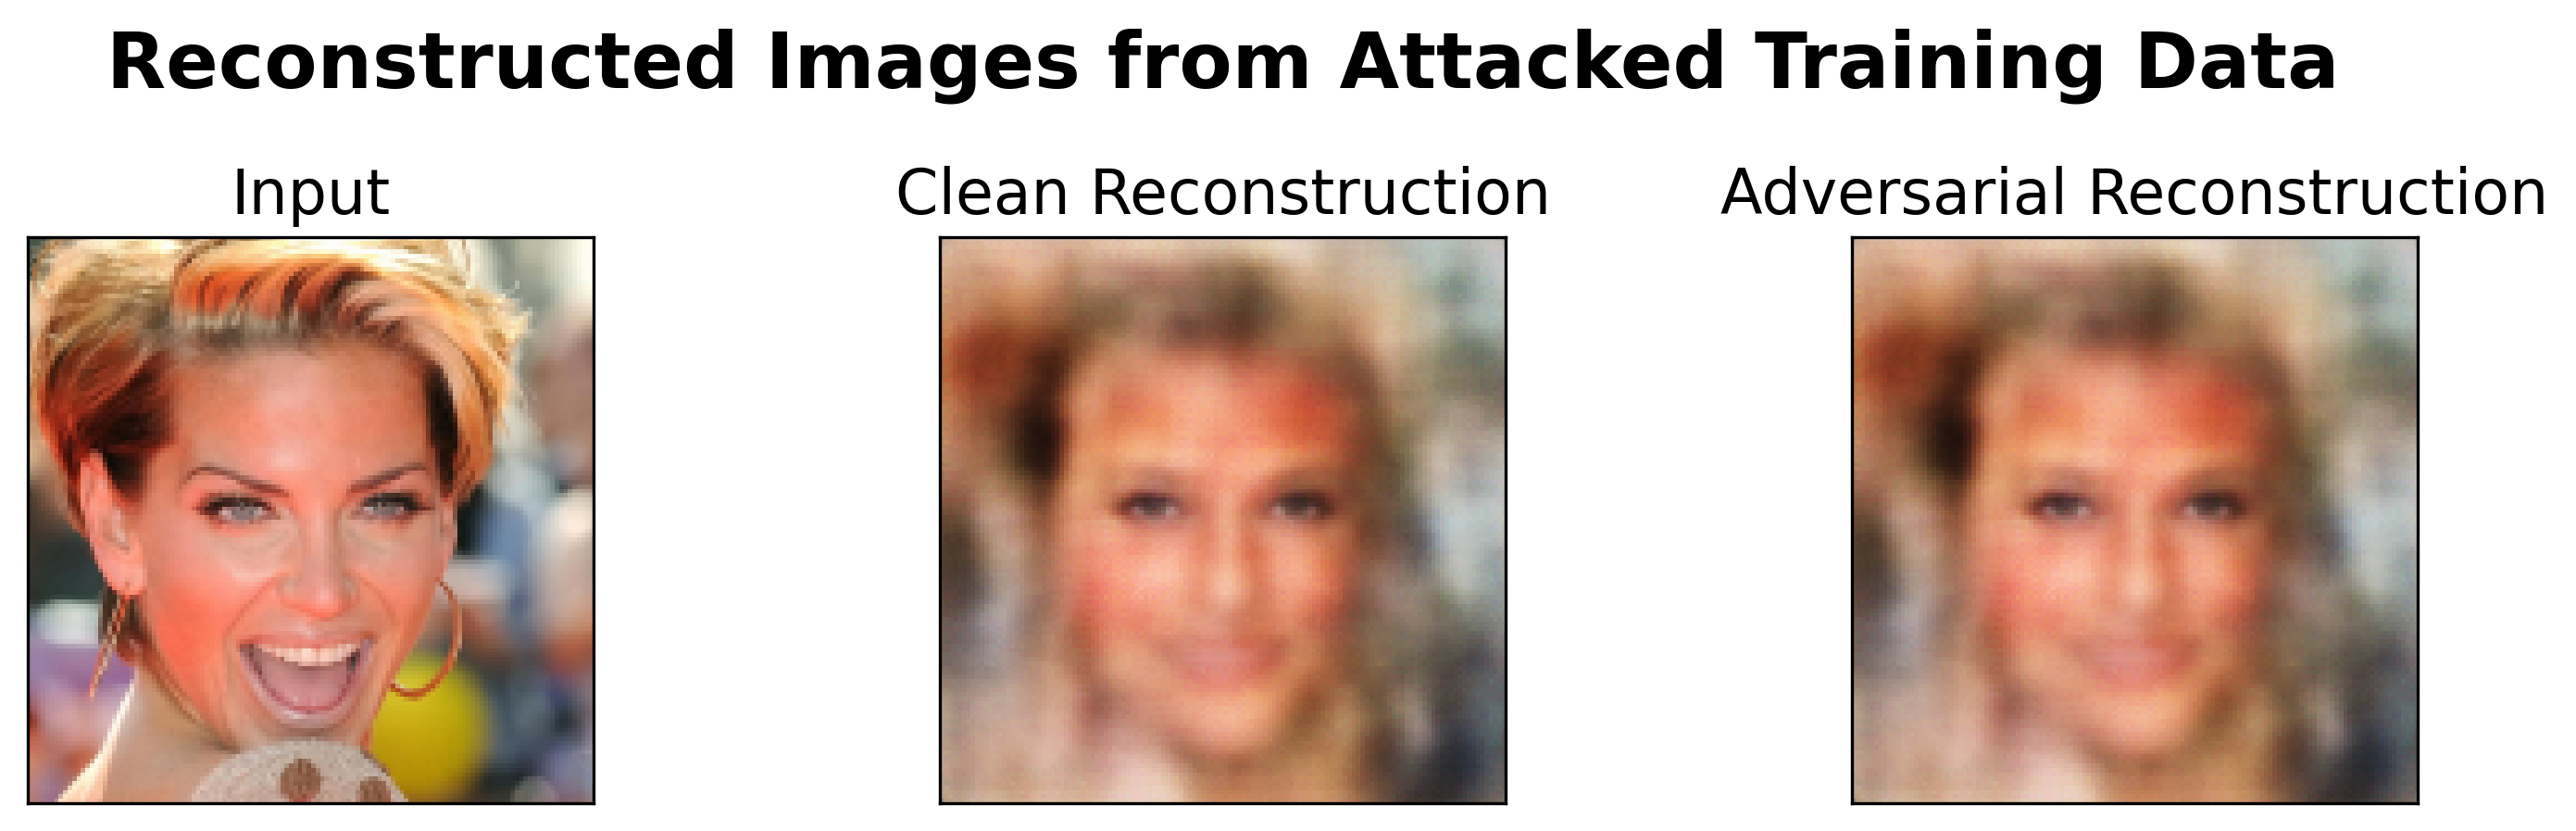

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

# Column titles
axes[0].set_title('Input', fontsize=16)
axes[1].set_title('Clean Reconstruction', fontsize=16)
axes[2].set_title('Adversarial Reconstruction', fontsize=16)

# Images
axes[0].imshow(all_data_im[0].permute(1, 2, 0).cpu().numpy())
axes[1].imshow(x_tildes[0][0].permute(1, 2, 0).cpu().numpy())
axes[2].imshow(x_tildes[0][0].permute(1, 2, 0).cpu().numpy())

# Remove ticks
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)

plt.suptitle('Reconstructed Images from Attacked Training Data', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/Attack-C-Visualization.png', bbox_inches='tight', dpi=300)
plt.show()